In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime

#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

LSTM

In [70]:
start = "2006-01-01"
end = datetime.date.today()

# Create synthetic portfolio dataset
ASSETS = [
    "AAPL",   # equity
    "MSFT",   # equity
    "SPY",    # equity index
    "TLT",    # bonds
    "IEF",    # bonds
    "GLD",    # gold
    "USO",    # oil
    "VNQ",    # REIT
    "QQQ",   # volatility index
    "DBC"     # commodities
]

def get_returns(assets, start, end):
    failed_tickers = []

    # Download data
    prices = yf.download(assets, start=start, end=end, group_by='ticker', auto_adjust=True)

    # Prepare adjusted close DataFrame
    adj_close = pd.DataFrame()

    if isinstance(prices.columns, pd.MultiIndex):
        # Multi-ticker download
        for ticker in assets:
            if ticker in prices.columns.get_level_values(0):
                adj_close[ticker] = prices[ticker]['Close']
            else:
                failed_tickers.append(ticker)
    else:
        # Single ticker
        ticker = assets[0] if isinstance(assets, list) else assets
        if 'Close' in prices.columns:
            adj_close[ticker] = prices['Close']
        else:
            print(ticker, " failed download")
            failed_tickers.append(ticker)

    # Compute log returns
    returns = np.log(adj_close / adj_close.shift(1))

    # Drop NaNs and inf values 
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    return returns, failed_tickers

In [3]:
# Generate LSTM dataset: synthetic portfolio
np.random.seed(4265)

def generate_sparse_weights(n_assets, k=10, alpha=0.3):
    weights = np.zeros(n_assets)
    # Pick k assets to have significant weight
    selected = np.random.choice(n_assets, k, replace=False)
    rand_weights = np.random.dirichlet([alpha]*k)
    weights[selected] = rand_weights

    # Give small random weight to other assets
    remaining_idx = [i for i in range(n_assets) if i not in selected]
    weights[remaining_idx] = np.random.dirichlet([0.05]*len(remaining_idx)) * 0.01  

    # Normalize weights
    weights /= weights.sum()
    return weights

def create_lstm_dataset(returns, n_portfolios=500, window=60, horizon=10):
    X = []
    y_vol = []
    y_dir = []

    for _ in range(n_portfolios):
        weights = generate_sparse_weights(returns.shape[1], k=10)

        port_returns = returns.values @ weights

        for i in range(0, len(port_returns) - window - horizon, window): 
            # Ensure no overlapping window for each portfolio weight generated
            past_window = port_returns[i:i+window]
            past_window = (past_window - np.mean(past_window)) / (np.std(past_window) + 1e-8)

            future_window = port_returns[i+window:i+window+horizon]

            # Ground truth future volatility
            future_vol = np.std(future_window) * np.sqrt(252)

            # Ground Truth portfolio future direction
            future_return = np.sum(future_window)
            threshold = 0.002 * np.sqrt(horizon)

            if future_return > threshold:
                direction = 1
            elif future_return < -threshold:
                direction = 0
            else:
                continue  # skip ambiguous samples

            X.append(past_window)
            y_vol.append(future_vol)
            y_dir.append(direction)
            
    X = np.array(X).reshape(-1, window, 1)
    y_vol = np.array(y_vol)
    y_dir = np.array(y_dir)

    return X, y_vol, y_dir

In [4]:
returns, prices = get_returns(ASSETS, start=start, end=end)

X, y_vol, y_dir = create_lstm_dataset(returns)

# Train-validation-test split: 80-10-10
n_samples = len(X)
train_end = int(0.8 * n_samples)
valid_end = int(0.9 * n_samples)

X_train, yv_train, yd_train = X[:train_end], y_vol[:train_end], y_dir[:train_end]
X_valid, yv_valid, yd_valid = X[train_end:valid_end], y_vol[train_end:valid_end], y_dir[train_end:valid_end]
X_test, yv_test, yd_test   = X[valid_end:], y_vol[valid_end:], y_dir[valid_end:]

[*********************100%***********************]  10 of 10 completed


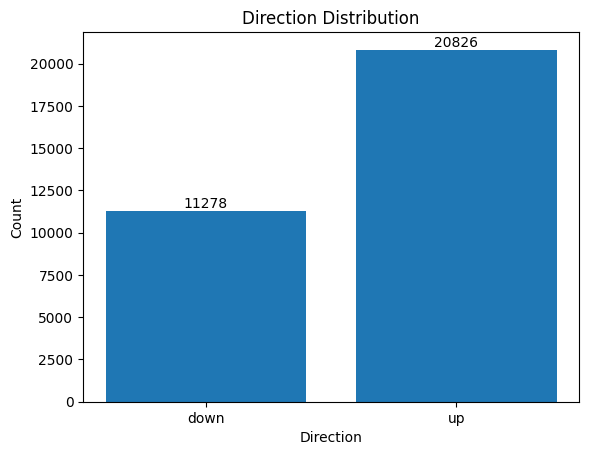

In [5]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(y_dir, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [6]:
# Undersample majority class
up_idx = np.where(yd_train == 1)[0]
down_idx = np.where(yd_train == 0)[0]

min_size = min(len(up_idx), len(down_idx))

up_sample = np.random.choice(up_idx, min_size, replace=False)
down_sample = np.random.choice(down_idx, min_size, replace=False)

balanced_idx = np.concatenate([up_sample, down_sample])
np.random.shuffle(balanced_idx)

X_train = X_train[balanced_idx]
yv_train = yv_train[balanced_idx]
yd_train = yd_train[balanced_idx]

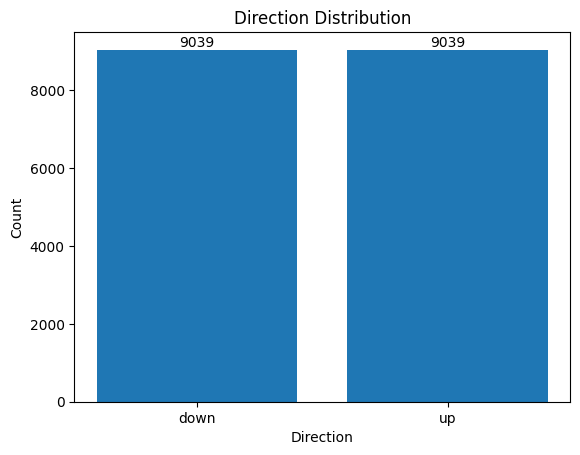

In [7]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(yd_train, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [8]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

yv_train = torch.tensor(yv_train, dtype=torch.float32).view(-1, 1)
yv_valid = torch.tensor(yv_valid, dtype=torch.float32).view(-1, 1)
yv_test  = torch.tensor(yv_test,  dtype=torch.float32).view(-1, 1)

yd_train = torch.tensor(yd_train, dtype=torch.float32).view(-1, 1)
yd_valid = torch.tensor(yd_valid, dtype=torch.float32).view(-1, 1)
yd_test  = torch.tensor(yd_test,  dtype=torch.float32).view(-1, 1)

class PortfolioDataset(Dataset):
    def __init__(self, X, y_vol, y_dir):
        self.X = X
        self.y_vol = y_vol
        self.y_dir = y_dir

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_vol[idx], self.y_dir[idx]


# Create Datasets
train_dataset = PortfolioDataset(X_train, yv_train, yd_train)
valid_dataset = PortfolioDataset(X_valid, yv_valid, yd_valid)
test_dataset = PortfolioDataset(X_test, yv_test, yd_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
print("Unique yd_train:", torch.unique(yd_train))
print("Sample yd_train:", yd_train[:10])

Unique yd_train: tensor([0., 1.])
Sample yd_train: tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.]])


In [10]:
# Regression loss
mse_loss = nn.MSELoss()

bce_loss = nn.BCEWithLogitsLoss()

In [99]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(LSTMModel, self).__init__()

        # LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)

        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        # Output heads
        self.volatility_head = nn.Linear(hidden_size2, 1)   # regression
        self.direction_head = nn.Sequential(
            nn.Linear(hidden_size2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )   # binary classification

    def forward(self, x):
        # x: (batch, seq_len, input_size)

        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        # Take last timestep
        out = out[:, -1, :]
        out = self.dropout2(out)

        vol_output = self.volatility_head(out)
        dir_output = self.direction_head(out)  

        return vol_output, dir_output

In [12]:
model = LSTMModel(input_size = X.shape[2])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

In [13]:
threshold = 0.5

In [14]:
all_preds = []
all_targets = []
all_probs = []

def evaluate(model, loader, mse_loss, bce_loss):
    model.eval()

    total_loss = 0
    total_vol_loss = 0
    total_dir_loss = 0
    total_mae = 0

    with torch.no_grad():
        for x, y_vol, y_dir in loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            
            vol_pred, dir_pred = model(x)
            #print("Logits std:", dir_pred.std().item())

            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            loss = 100 * loss_vol + 2 * loss_dir

            mae = torch.mean(torch.abs(vol_pred - y_vol))

            # Apply sigmoid before threshold
            probs = torch.sigmoid(dir_pred)
            preds = (probs > threshold).float()

            # check mean probs
            print("Mean prob:", probs.mean().item())
            print(probs.min().item(), probs.max().item())
            print("Predicted positives:", preds.sum().item())
            print("Actual positives:", y_dir.sum().item())

            all_preds.extend(dir_pred.view(-1).cpu().numpy())
            all_targets.extend(y_dir.view(-1).cpu().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())  

            total_loss += loss.item()
            total_vol_loss += loss_vol.item()
            total_dir_loss += loss_dir.item()
            total_mae += mae.item()

    auc = roc_auc_score(all_targets, all_probs)

    n = len(loader)
    return {
        "loss": total_loss / n,
        "vol_loss": total_vol_loss / n,
        "dir_loss": total_dir_loss / n,
        "mae": total_mae / n,
        "auc": auc,
    }

In [15]:
train_loss =  []
val_loss = []
train_vol_loss = []
val_vol_loss = []
train_dir_loss = [] 
val_dir_loss = []
train_mae = []
val_mae = []
train_auc = []
val_auc = []

def train(model, train_loader, val_loader, epochs, optimizer, mse_loss, bce_loss):
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 2
    trained_epochs = 0

    for epoch in range(epochs):
        model.train()

        for x, y_vol, y_dir in train_loader:
            optimizer.zero_grad()

            vol_pred, dir_pred = model(x)

            # Ensure shape consistency
            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            loss = 100 * loss_vol + 2 * loss_dir

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Evaluate
        train_metrics = evaluate(model, train_loader, mse_loss, bce_loss)
        val_metrics   = evaluate(model, val_loader, mse_loss, bce_loss)
        
        # For plots
        train_loss.append(train_metrics['loss'])
        val_loss.append(val_metrics['loss'])
        train_vol_loss.append(train_metrics['vol_loss'])
        val_vol_loss.append(val_metrics['vol_loss'])
        train_dir_loss.append(train_metrics['dir_loss'])
        val_dir_loss.append(val_metrics['dir_loss'])
        train_mae.append(train_metrics['mae'])
        val_mae.append(val_metrics['mae'])
        train_auc.append(train_metrics['auc'])
        val_auc.append(val_metrics['auc'])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train total Loss: {train_metrics['loss']:.4f} | Val total Loss: {val_metrics['loss']:.4f}")
        print(f"Train vol Loss: {train_metrics['vol_loss']:.4f} | Val vol Loss: {val_metrics['vol_loss']:.4f}")
        print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f}")

        trained_epochs += 1
        # Early stopping
        current_val_loss = val_metrics['loss']
        min_delta = 1e-4

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0

            # (optional) save best model
            best_model_state = model.state_dict()

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            EPOCHS = epoch+1
            break
    return trained_epochs, best_model_state

In [16]:
EPOCHS = 20
train(model, train_loader, val_loader, EPOCHS, optimizer, mse_loss, bce_loss)

# Save the model state_dict
torch.save(model.state_dict(), 'model_weights.pth')

Mean prob: 0.5004189610481262
0.49461236596107483 0.5061384439468384
Predicted positives: 36.0
Actual positives: 35.0
Mean prob: 0.5011506080627441
0.4947751462459564 0.5055528879165649
Predicted positives: 45.0
Actual positives: 25.0
Mean prob: 0.5011910200119019
0.49739721417427063 0.5065021514892578
Predicted positives: 42.0
Actual positives: 34.0
Mean prob: 0.5011032223701477
0.4946744441986084 0.5059966444969177
Predicted positives: 44.0
Actual positives: 33.0
Mean prob: 0.5016312599182129
0.49652034044265747 0.5069314241409302
Predicted positives: 48.0
Actual positives: 33.0
Mean prob: 0.5006044507026672
0.49562332034111023 0.5067974925041199
Predicted positives: 34.0
Actual positives: 35.0
Mean prob: 0.5009055137634277
0.49518534541130066 0.5077316761016846
Predicted positives: 38.0
Actual positives: 35.0
Mean prob: 0.5011365413665771
0.4965428113937378 0.5055473446846008
Predicted positives: 42.0
Actual positives: 30.0
Mean prob: 0.5011855959892273
0.4969359040260315 0.50716346

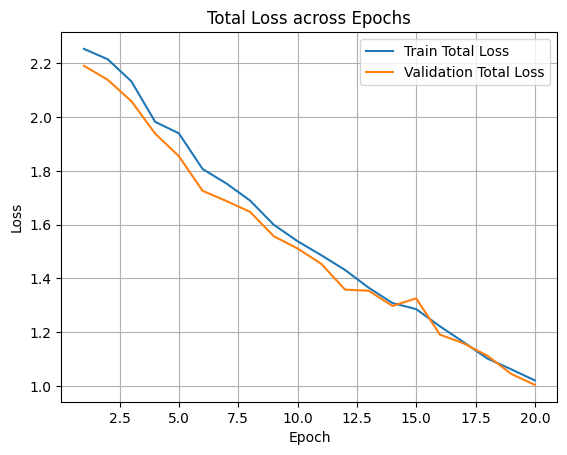

In [17]:
# Plot loss over epochs
plt.figure()
plt.plot(range(1, EPOCHS+1), train_loss, label='Train Total Loss')
plt.plot(range(1, EPOCHS+1), val_loss, label='Validation Total Loss')
plt.title('Total Loss across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

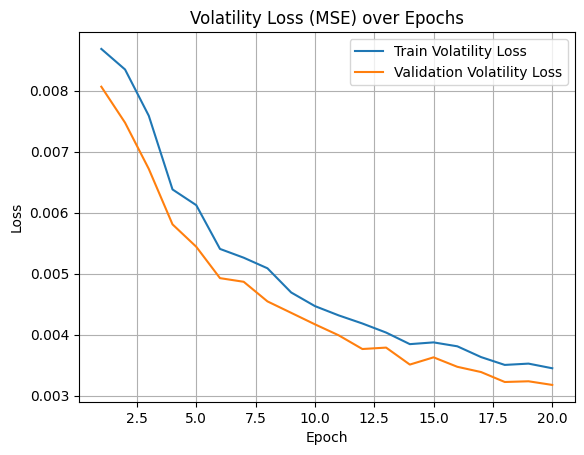

In [18]:
# Plot volatility MSE over epochs
plt.figure()
plt.plot(range(1, EPOCHS+1),train_vol_loss, label='Train Volatility Loss')
plt.plot(range(1, EPOCHS+1),val_vol_loss, label='Validation Volatility Loss')
plt.title('Volatility Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

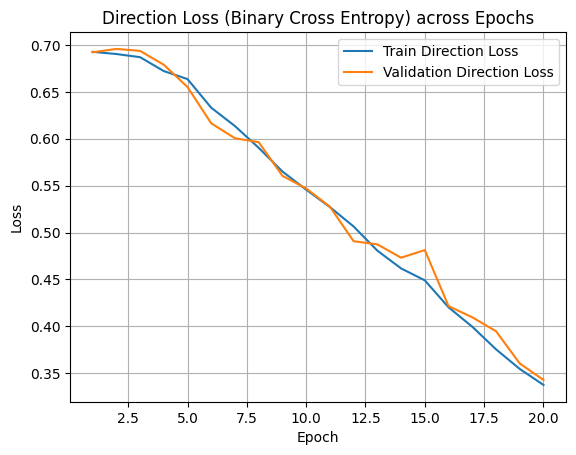

In [19]:
# PLot Binary Cross Entropy Loss
plt.figure()
plt.plot(range(1, EPOCHS+1),train_dir_loss, label='Train Direction Loss')
plt.plot(range(1, EPOCHS+1),val_dir_loss, label='Validation Direction Loss')
plt.title('Direction Loss (Binary Cross Entropy) across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

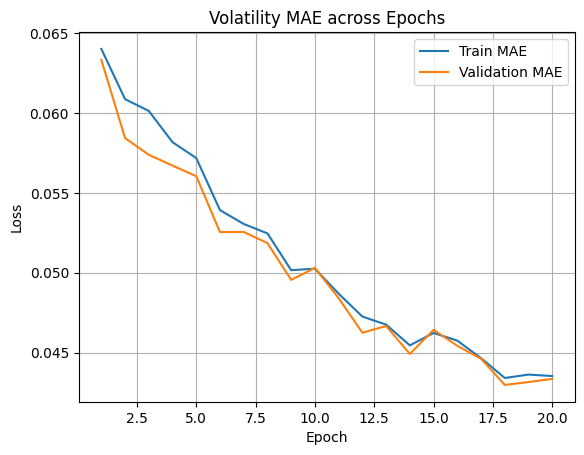

In [20]:
# PLot volatility MAE across epochs
plt.figure()
plt.plot(range(1, EPOCHS+1), train_mae, label='Train MAE')
plt.plot(range(1, EPOCHS+1), val_mae, label='Validation MAE')
plt.title('Volatility MAE across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


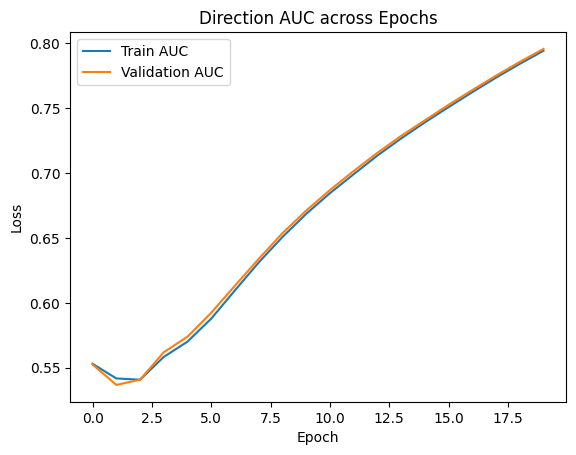

In [21]:
# Plot direction AUC across epochs 
plt.figure()
plt.plot(train_auc, label='Train AUC')
plt.plot(val_auc, label='Validation AUC')
plt.title('Direction AUC across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Future volatility of portfolio
def calculate_future_risk(model, tickers_weights_dictionary):
    X_input = portfolio_to_lstm_input(tickers_weights_dictionary)

    vol_pred, dir_pred = model.predict(X_input)

    vol = vol_pred[0][0] 

    prob_up = dir_pred[0][0]

    direction = "Up" if prob_up > threshold else "Down"

    # Confidence = probability distance from 0.5
    confidence = abs(prob_up - threshold) * 2   # scaled to [0,1]

    return {
        "predicted_volatility": vol,
        "predicted_direction": direction,
        "confidence": confidence,
        "prob_up": prob_up
    }

In [23]:
all_preds = []
all_targets = []
all_probs = []
test_metrics = evaluate(model, test_loader, mse_loss, bce_loss)

Mean prob: 0.5215250253677368
0.0019141638185828924 0.9518513679504395
Predicted positives: 38.0
Actual positives: 39.0
Mean prob: 0.6286816596984863
0.0022570020519196987 0.9756941795349121
Predicted positives: 46.0
Actual positives: 47.0
Mean prob: 0.5378850102424622
0.002581395208835602 0.9621502757072449
Predicted positives: 38.0
Actual positives: 37.0
Mean prob: 0.6390340328216553
0.001967659452930093 0.9749851226806641
Predicted positives: 45.0
Actual positives: 47.0
Mean prob: 0.5889458656311035
0.001204490545205772 0.962089478969574
Predicted positives: 42.0
Actual positives: 42.0
Mean prob: 0.4941173791885376
0.0030411442276090384 0.947481632232666
Predicted positives: 37.0
Actual positives: 33.0
Mean prob: 0.5988235473632812
0.005889795254915953 0.9813373684883118
Predicted positives: 42.0
Actual positives: 43.0
Mean prob: 0.5313646793365479
0.0036561377346515656 0.9541504979133606
Predicted positives: 36.0
Actual positives: 42.0
Mean prob: 0.5866466164588928
0.00486472994089

In [24]:
print("Test set Volatility Evaluation:")
print(f"Test MSE: {test_metrics['vol_loss']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")

print("Test set Direction Evaluation:")
print(f"Test AUC: {test_metrics['auc']:.4f}")

Test set Volatility Evaluation:
Test MSE: 0.0036
Test MAE: 0.0440
Test set Direction Evaluation:
Test AUC: 0.9505


Confusion Matrix:
[[1008  114]
 [ 284 1805]]


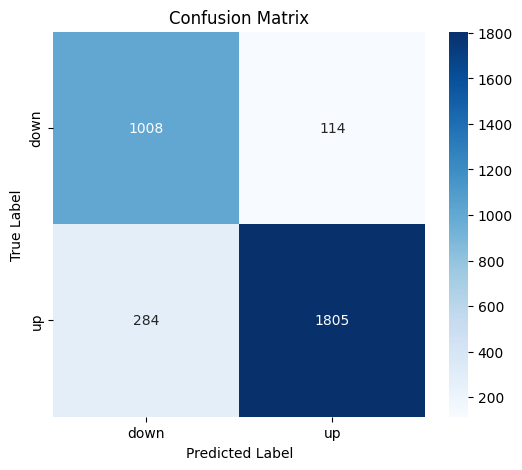

In [25]:
# Convert probabilities to 0/1
y_dir_pred_class = (np.array(all_preds) > threshold).astype(int)

# print(np.unique(yd_test))

# Confusion matrix
cm = confusion_matrix(yd_test, y_dir_pred_class)
print("Confusion Matrix:")
print(cm)

labels = ['down', 'up']
plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
   annot=True,
   fmt="d",
   cmap="Blues",
   xticklabels=labels,
   yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [26]:
# Classification Report

report = classification_report(yd_test, y_dir_pred_class, target_names=["Down", "Up"])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Down       0.78      0.90      0.84      1122
          Up       0.94      0.86      0.90      2089

    accuracy                           0.88      3211
   macro avg       0.86      0.88      0.87      3211
weighted avg       0.88      0.88      0.88      3211



Evaluating performance of Agentic tools on synthetic portfolios

In [62]:
# Helper: Fetch price data
# "start": "2020-01-01", "end": "today"

start = "2020-01-01"
end = datetime.date.today()
def get_price_data(tickers, start=start, end=end):
    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True  # ensures adjusted prices
    )

    # Case 1: MultiIndex (multiple tickers)
    if isinstance(data.columns, pd.MultiIndex):
        if "Close" in data.columns.get_level_values(0):
            data = data["Close"]
        else:
            raise ValueError("Close prices not found in data")

    # Case 2: Single ticker
    else:
        if "Close" in data.columns:
            data = data[["Close"]]
        else:
            raise ValueError("Close column not found")

    return data.dropna()


# Calculate Risk Metrics

# Normalization
def clamp(x, min_val=0, max_val=1):
    return max(min(x, max_val), min_val) 

def calculate_risk_metrics(tickers_weights_dictionary):
    tickers = list(tickers_weights_dictionary.keys())
    weights = np.array(list(tickers_weights_dictionary.values()))

    # Normalize weights 
    weights = weights / np.sum(weights)

    prices = get_price_data(tickers)
    returns = prices.pct_change().dropna()

    # Portfolio returns
    portfolio_returns = returns.dot(weights)

    # ---- Metrics ----
    # Volatility (annualized)
    volatility = np.std(portfolio_returns) * np.sqrt(252)

    # VaR (95% confidence)
    VaR = np.percentile(portfolio_returns, 5)

    # Sharpe Ratio (assume risk-free rate = 0)
    sharpe = np.mean(portfolio_returns) / np.std(portfolio_returns) * np.sqrt(252)

    # Max Drawdown
    cumulative = (1 + portfolio_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    # Correlation (average pairwise correlation)
    corr_matrix = returns.corr()
    avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean()

    # Concentration (Herfindahl index)
    concentration = np.sum(weights**2)

    # Normalization (bounded 0–1) 
    vol_norm = clamp(volatility / 0.4)

    var_norm = clamp(abs(VaR) / 0.1)

    # Sharpe: map inversely without clamping to 0
    sharpe_norm = clamp(max(0.5 - sharpe/4, 0), 0, 1)

    conc_norm = clamp(concentration)

    # Correlation: map from [-1, 1] to [0, 1]
    corr_norm = clamp((avg_corr + 1) / 2)

    # Include drawdown
    dd_norm = clamp(abs(max_drawdown) / 0.5)

    metrics = {
        "vol_norm": vol_norm,
        "var_norm": var_norm,
        "sharpe_norm": sharpe_norm,
        "conc_norm": conc_norm,
        "corr_norm": corr_norm,
        "dd_norm": dd_norm,
        # Raw metrics
        "raw": {
            "volatility": volatility,
            "VaR": VaR,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
            "correlation": avg_corr,
            "concentration": concentration
        }
    }

    return metrics


# Risk classification Function
def classify_risk_level(tickers_weights_dictionary):

    metrics = calculate_risk_metrics(tickers_weights_dictionary)

    risk_score = (
        0.25 * metrics["vol_norm"] +
        0.15 * metrics["var_norm"] +
        0.10 * metrics["sharpe_norm"] +
        0.15 * metrics["conc_norm"] +
        0.15 * metrics["corr_norm"] +
        0.20 * metrics["dd_norm"]
    )

    if risk_score < 0.35:
        volatility_label = "Low"
    elif risk_score <= 0.60:
        volatility_label = "Medium"
    else:
        volatility_label = "High"

    return {
        "risk_score": risk_score,
        "risk_level": volatility_label,
        "metrics": metrics
    }

Testing current portfolio risk tool on synthetic portfolios:
- balanced portfolio that is diversified
- aggressive portfolio that is tech focused

In [82]:
portfolio_balanced = {
    "AAPL":0.20,
    "MSFT":0.20, 
    "SPY": 0.20, 
    "TLT":0.15, 
    "GLD":0.15, 
    "VNQ":0.10
}
results = classify_risk_level(portfolio_balanced)

[*********************100%***********************]  6 of 6 completed


In [64]:
results

{'risk_score': 0.3762558086430161,
 'risk_level': 'Medium',
 'metrics': {'vol_norm': 0.413219686446561,
  'var_norm': 0.1581402966972336,
  'sharpe_norm': 0.27199539675900686,
  'conc_norm': 0.17499999999999993,
  'corr_norm': 0.6495079305947293,
  'dd_norm': 0.4917705663084038,
  'raw': {'volatility': 0.1652878745786244,
   'VaR': -0.01581402966972336,
   'sharpe': 0.9120184129639726,
   'max_drawdown': -0.2458852831542019,
   'correlation': 0.2990158611894586,
   'concentration': 0.17499999999999993}}}

In [83]:
portfolio_aggressive = {
    "AAPL":0.20, 
    "MSFT":0.20, 
    "QQQ":0.25, 
    "NVDA":0.20, 
    "TSLA":0.15
}
results2 = classify_risk_level(portfolio_aggressive)

[*********************100%***********************]  5 of 5 completed


In [66]:
results2

{'risk_score': 0.6102891233905476,
 'risk_level': 'High',
 'metrics': {'vol_norm': 0.8384013443963606,
  'var_norm': 0.3247803735755421,
  'sharpe_norm': 0.20826699782224167,
  'conc_norm': 0.20500000000000002,
  'corr_norm': 0.8204369196906042,
  'dd_norm': 0.8866474675965567,
  'raw': {'volatility': 0.33536053775854424,
   'VaR': -0.03247803735755422,
   'sharpe': 1.1669320087110333,
   'max_drawdown': -0.44332373379827833,
   'correlation': 0.6408738393812083,
   'concentration': 0.20500000000000002}}}